In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

n = np.random.randint(600, 701)

# State -> Correct districts mapping
state_districts = {
    "Maharashtra": [
        "Pune", "Mumbai", "Nashik", "Nagpur", "Ahmednagar",
        "Satara", "Kolhapur", "Thane", "Aurangabad",
        "Solapur", "Nanded", "Sangli"
    ],
    "Gujarat": [
        "Surat", "Vadodara", "Ahmedabad", "Rajkot", "Bhavnagar"
    ],
    "Madhya Pradesh": [
        "Indore", "Bhopal", "Chhatarpur", "Jabalpur", "Gwalior"
    ],
    "Karnataka": [
        "Mangaluru", "Udupi", "Bengaluru", "Mysuru", "Hubballi"
    ],
    "Telangana": [
        "Nizamabad", "Hyderabad", "Warangal", "Karimnagar"
    ],
    "Rajasthan": [
        "Nagaur", "Ajmer", "Jaisalmer", "Jaipur", "Jodhpur"
    ],
    "Uttar Pradesh": [
        "Varanasi", "Agra", "Kanpur", "Noida", "Lucknow"
    ],
    "Bihar": [
        "Darbhanga", "Bhagalpur", "Patna", "Gaya", "Muzaffarpur"
    ],
    "Odisha": [
        "Puri", "Bhubaneswar", "Cuttack", "Sambalpur", "Balasore"
    ],
    "Tamil Nadu": [
        "Coimbatore", "Chennai", "Madurai", "Salem", "Tiruchirappalli"
    ],
    "New Delhi": [
        "Central Delhi", "North Delhi", "South Delhi",
        "East Delhi", "West Delhi"
    ],
    "Punjab": [
        "Ludhiana", "Amritsar", "Kapurthala", "Patiala",
        "Jalandhar", "Bathinda"
    ],
    "Haryana": [
        "Karnal", "Ambala", "Panipat", "Sonipat",
        "Gurugram", "Faridabad"
    ]
}

states = list(state_districts.keys())

project_types = [
    "National Highway",
    "State Highway",
    "Railway",
    "Metro",
    "Industrial Corridor",
    "Airport",
    "Dam",
    "Expressway"
]

land_types = [
    "Agricultural",
    "Residential",
    "Commercial",
    "Industrial",
    "Forest",
    "Government"
]

owner_types = [
    "Individual",
    "Joint Family",
    "Company",
    "Government",
    "Trust"
]

consent_statuses = [
    "Pending",
    "Obtained",
    "Disputed"
]

compensation_statuses = [
    "Pending",
    "Partial",
    "Paid"
]

approval_statuses = [
    "Pending",
    "Approved",
    "Rejected"
]

rehabilitation_statuses = [
    "Not Required",
    "Pending",
    "In Progress",
    "Completed"
]

grievance_statuses = [
    "None",
    "Open",
    "Resolved"
]

dispute_levels = [
    "None",
    "Low",
    "Medium",
    "High"
]

# Generate state first
state_data = np.random.choice(states, n)

# Generate district according to the selected state
district_data = [
    np.random.choice(state_districts[state])
    for state in state_data
]

data = {
    "land_id": [
        f"LA{2026}{i:04d}"
        for i in range(1, n + 1)
    ],

    "state": state_data,

    "district": district_data,

    "city_village": [
        f"Village_{np.random.randint(1, 101)}"
        for _ in range(n)
    ],

    "project_type": np.random.choice(
        project_types, n
    ),

    "land_area_acres": np.round(
        np.random.uniform(0.5, 50, n), 2
    ),

    "land_type": np.random.choice(
        land_types, n
    ),

    "owner_type": np.random.choice(
        owner_types, n
    ),

    "owners_count": np.random.randint(
        1, 8, n
    ),

    "ownership_dispute": np.random.choice(
        ["Yes", "No"],
        n,
        p=[0.25, 0.75]
    ),

    "dispute_level": np.random.choice(
        dispute_levels,
        n,
        p=[0.55, 0.15, 0.20, 0.10]
    ),

    "notice_issued": np.random.choice(
        ["Yes", "No"],
        n,
        p=[0.85, 0.15]
    ),

    "consent_status": np.random.choice(
        consent_statuses,
        n,
        p=[0.35, 0.55, 0.10]
    ),

    "valuation_amount": np.round(
        np.random.uniform(2, 200, n) * 100000,
        0
    ),

    "compensation_amount": np.round(
        np.random.uniform(2, 250, n) * 100000,
        0
    ),

    "compensation_status": np.random.choice(
        compensation_statuses,
        n,
        p=[0.30, 0.20, 0.50]
    ),

    "payment_delay_days": np.random.randint(
        0, 181, n
    ),

    "approval_status": np.random.choice(
        approval_statuses,
        n,
        p=[0.30, 0.65, 0.05]
    ),

    "approval_delay_days": np.random.randint(
        0, 151, n
    ),

    "rehabilitation_status": np.random.choice(
        rehabilitation_statuses,
        n,
        p=[0.45, 0.20, 0.15, 0.20]
    ),

    "grievance_status": np.random.choice(
        grievance_statuses,
        n,
        p=[0.55, 0.20, 0.25]
    ),

    "acquisition_percent": np.round(
        np.random.uniform(5, 100, n), 2
    ),

    "total_delay_days": np.random.randint(
        0, 365, n
    )
}

df = pd.DataFrame(data)

# Calculate acquisition status
def get_status(x):
    if x < 25:
        return "Initial"
    elif x < 50:
        return "In Progress"
    elif x < 80:
        return "Advanced"
    elif x < 100:
        return "Near Completion"
    else:
        return "Completed"

df["acquisition_status"] = (
    df["acquisition_percent"].apply(get_status)
)

# Risk calculation
def calculate_risk(row):

    score = 0

    if row["ownership_dispute"] == "Yes":
        score += 25

    if row["dispute_level"] == "Medium":
        score += 15
    elif row["dispute_level"] == "High":
        score += 30

    if row["payment_delay_days"] > 90:
        score += 20

    if row["approval_delay_days"] > 90:
        score += 15

    if row["grievance_status"] == "Open":
        score += 10

    if row["acquisition_percent"] < 40:
        score += 15

    if score >= 50:
        return "High"
    elif score >= 25:
        return "Medium"
    else:
        return "Low"

df["risk_level"] = df.apply(
    calculate_risk,
    axis=1
)

# Estimated completion
df["expected_completion_days"] = (
    365 - (df["acquisition_percent"] * 3.2)
    + df["total_delay_days"] * 0.5
).round().astype(int)

# Shuffle rows
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# Display
print("Number of records:", len(df))
print("Number of attributes:", len(df.columns))

print("\nDataset information:")
print(df.info())

# Save CSV
df.to_csv(
    "SIH26016_Land_Acquisition_Synthetic_Data.csv",
    index=False
)

Number of records: 651
Number of attributes: 26

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 651 entries, 0 to 650
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   land_id                   651 non-null    str    
 1   state                     651 non-null    str    
 2   district                  651 non-null    str    
 3   city_village              651 non-null    str    
 4   project_type              651 non-null    str    
 5   land_area_acres           651 non-null    float64
 6   land_type                 651 non-null    str    
 7   owner_type                651 non-null    str    
 8   owners_count              651 non-null    int32  
 9   ownership_dispute         651 non-null    str    
 10  dispute_level             651 non-null    str    
 11  notice_issued             651 non-null    str    
 12  consent_status            651 non-null    str    
 13  valuat

In [2]:
df

,land_id,state,district,city_village,project_type,land_area_acres,land_type,owner_type,owners_count,ownership_dispute,...,payment_delay_days,approval_status,approval_delay_days,rehabilitation_status,grievance_status,acquisition_percent,total_delay_days,acquisition_status,risk_level,expected_completion_days
0,LA20260639,Odisha,Cuttack,Village_74,Expressway,44.01,Residential,Government,1,No,...,54,Pending,98,Pending,None,54.27,66,Advanced,Low,224
1,LA20260265,New Delhi,South Delhi,Village_46,Metro,34.60,Industrial,Company,5,Yes,...,153,Approved,148,Not Required,None,81.07,107,Near Completion,High,159
2,LA20260260,Telangana,Warangal,Village_18,Industrial Corridor,27.34,Agricultural,Government,3,Yes,...,114,Approved,30,Not Required,Resolved,75.59,228,Advanced,Medium,237
3,LA20260496,Uttar Pradesh,Agra,Village_76,State Highway,10.50,Government,Joint Family,6,No,...,14,Approved,6,In Progress,None,90.91,148,Near Completion,Low,148
4,LA20260073,Bihar,Muzaffarpur,Village_22,Industrial Corridor,30.51,Forest,Trust,4,No,...,128,Rejected,100,Not Required,None,75.25,275,Advanced,Medium,262
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
646,LA20260072,Gujarat,Bhavnagar,Village_73,Expressway,24.61,Agricultural,Company,3,Yes,...,133,Approved,71,Not Required,Resolved,20.39,240,Initial,High,420
647,LA20260107,Maharashtra,Mumbai,Village_10,State Highway,15.51,Government,Trust,5,No,...,17,Approved,114,Not Required,Resolved,27.57,62,In Progress,Medium,308
648,LA20260271,Haryana,Ambala,Village_16,Railway,0.96,Forest,Joint Family,2,No,...,86,Approved,8,Not Required,None,73.82,214,Advanced,Low,236
649,LA20260436,Haryana,Karnal,Village_53,Dam,24.49,Commercial,Company,3,No,...,152,Approved,117,Completed,None,21.54,214,Initial,High,403


In [3]:
len(df)

651

In [4]:
df.columns.tolist()

['land_id',
 'state',
 'district',
 'city_village',
 'project_type',
 'land_area_acres',
 'land_type',
 'owner_type',
 'owners_count',
 'ownership_dispute',
 'dispute_level',
 'notice_issued',
 'consent_status',
 'valuation_amount',
 'compensation_amount',
 'compensation_status',
 'payment_delay_days',
 'approval_status',
 'approval_delay_days',
 'rehabilitation_status',
 'grievance_status',
 'acquisition_percent',
 'total_delay_days',
 'acquisition_status',
 'risk_level',
 'expected_completion_days']

In [5]:
df.describe()

,land_area_acres,owners_count,valuation_amount,compensation_amount,payment_delay_days,approval_delay_days,acquisition_percent,total_delay_days,expected_completion_days
count,651.000000,651.000000,6.510000e+02,6.510000e+02,651.000000,651.000000,651.000000,651.000000,651.000000
mean,25.677727,4.156682,1.015050e+07,1.263625e+07,90.084485,72.341014,51.391920,185.125960,293.102919
std,14.343691,2.003082,5.630911e+06,7.164460e+06,52.149465,43.156108,27.301931,106.715147,100.276940
min,0.660000,1.000000,2.251080e+05,2.722110e+05,0.000000,0.000000,5.100000,0.000000,54.000000
25%,13.155000,2.000000,5.372014e+06,6.842132e+06,47.000000,36.500000,29.315000,92.000000,220.000000
50%,26.210000,4.000000,1.046271e+07,1.274028e+07,89.000000,71.000000,49.710000,182.000000,295.000000
75%,38.350000,6.000000,1.475313e+07,1.895175e+07,134.000000,110.000000,75.375000,277.500000,368.000000
max,49.920000,7.000000,1.999702e+07,2.495620e+07,180.000000,150.000000,99.810000,364.000000,520.000000


In [6]:
df.isnull().sum()

land_id                     0
state                       0
district                    0
city_village                0
project_type                0
land_area_acres             0
land_type                   0
owner_type                  0
owners_count                0
ownership_dispute           0
dispute_level               0
notice_issued               0
consent_status              0
valuation_amount            0
compensation_amount         0
compensation_status         0
payment_delay_days          0
approval_status             0
approval_delay_days         0
rehabilitation_status       0
grievance_status            0
acquisition_percent         0
total_delay_days            0
acquisition_status          0
risk_level                  0
expected_completion_days    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
total_land = df["land_area_acres"].sum()

print("Total Land Area:", round(total_land, 2), "acres")

Total Land Area: 16716.2 acres


In [9]:
df["acquisition_percent"].describe()


count    651.000000
mean      51.391920
std       27.301931
min        5.100000
25%       29.315000
50%       49.710000
75%       75.375000
max       99.810000
Name: acquisition_percent, dtype: float64

In [10]:
df["approval_delay_days"].describe()


count    651.000000
mean      72.341014
std       43.156108
min        0.000000
25%       36.500000
50%       71.000000
75%      110.000000
max      150.000000
Name: approval_delay_days, dtype: float64

In [11]:
df["acquisition_status"].value_counts()


acquisition_status
Advanced           194
In Progress        190
Initial            137
Near Completion    130
Name: count, dtype: int64

In [12]:
df["acquisition_status"].value_counts(
    normalize=True
) * 100



acquisition_status
Advanced           29.800307
In Progress        29.185868
Initial            21.044547
Near Completion    19.969278
Name: proportion, dtype: float64

In [13]:
df["risk_level"].value_counts()


risk_level
Medium    295
Low       187
High      169
Name: count, dtype: int64

In [14]:
df["risk_level"].value_counts(
    normalize=True
) * 100


risk_level
Medium    45.314900
Low       28.725038
High      25.960061
Name: proportion, dtype: float64

In [15]:
df["compensation_status"].value_counts()


compensation_status
Paid       342
Pending    182
Partial    127
Name: count, dtype: int64

In [16]:
df["ownership_dispute"].value_counts()



ownership_dispute
No     484
Yes    167
Name: count, dtype: int64

In [17]:
df["project_type"].value_counts()


project_type
State Highway          95
Metro                  89
Dam                    86
Industrial Corridor    85
Airport                79
National Highway       79
Railway                71
Expressway             67
Name: count, dtype: int64

In [18]:
df["land_type"].value_counts()


land_type
Forest          119
Agricultural    114
Commercial      113
Industrial      108
Government      103
Residential      94
Name: count, dtype: int64

In [19]:
df["district"].value_counts()

district
Jalandhar     18
Jodhpur       16
Coimbatore    16
Warangal      15
Mangaluru     15
              ..
Ambala         4
Nagaur         4
Sangli         4
Aurangabad     3
Ahmednagar     2
Name: count, Length: 73, dtype: int64

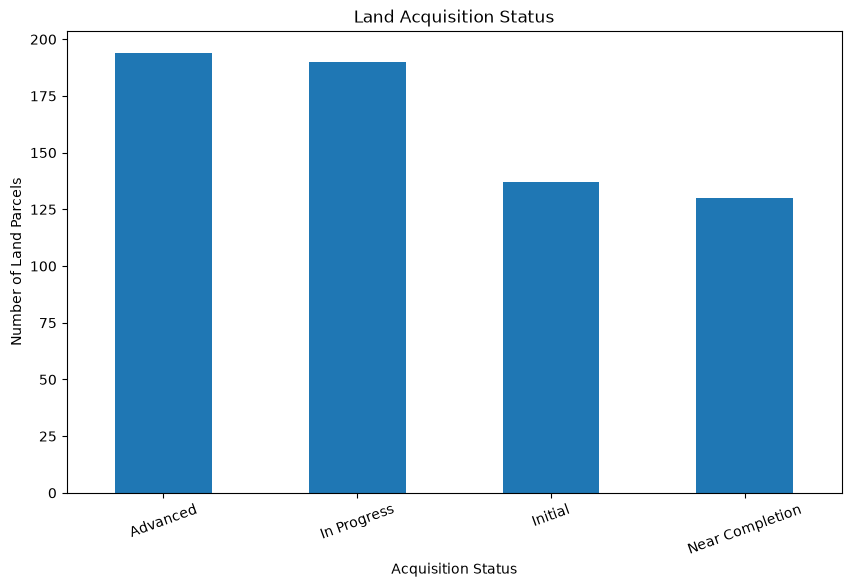

In [20]:
plt.figure(figsize=(10, 6))

df["acquisition_status"].value_counts().plot(
    kind="bar"
)

plt.title("Land Acquisition Status")
plt.xlabel("Acquisition Status")
plt.ylabel("Number of Land Parcels")

plt.xticks(rotation=20)
plt.show()

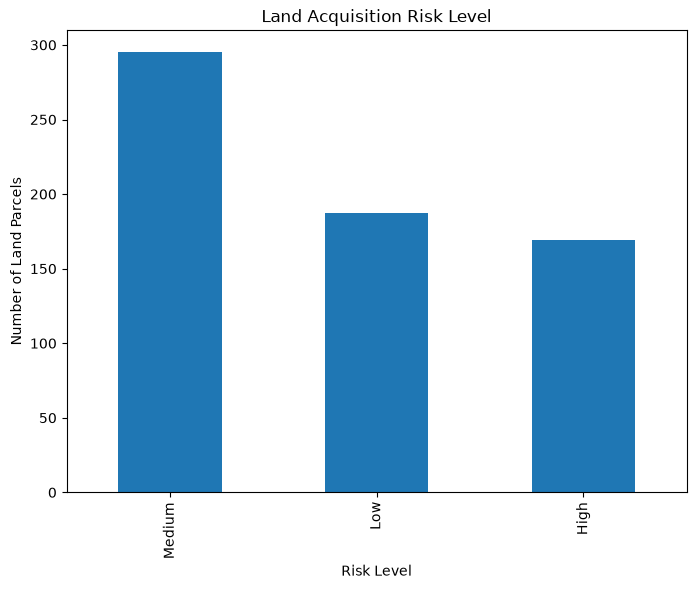

In [21]:
plt.figure(figsize=(8, 6))

df["risk_level"].value_counts().plot(
    kind="bar"
)

plt.title("Land Acquisition Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Number of Land Parcels")

plt.show()

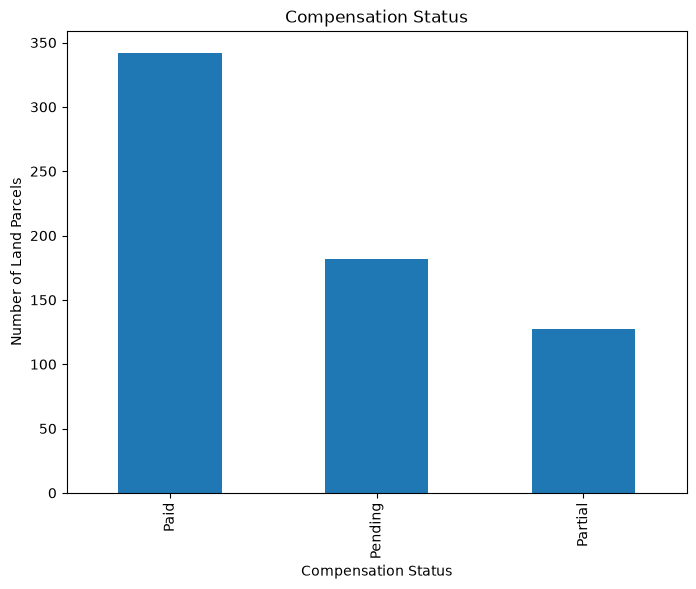

In [22]:
plt.figure(figsize=(8, 6))

df["compensation_status"].value_counts().plot(
    kind="bar"
)

plt.title("Compensation Status")
plt.xlabel("Compensation Status")
plt.ylabel("Number of Land Parcels")

plt.show()

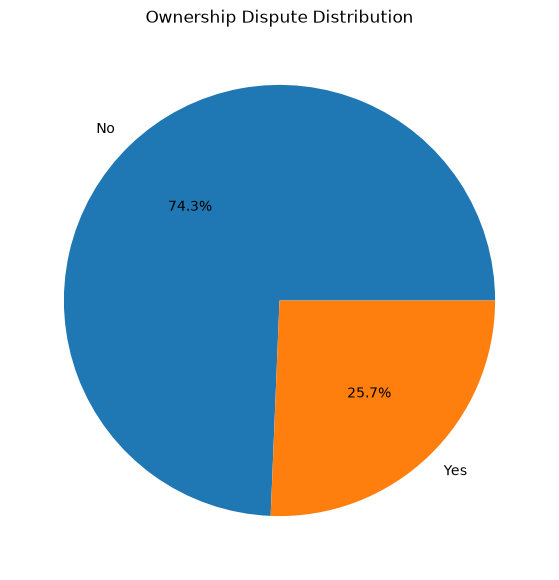

In [23]:
plt.figure(figsize=(7, 7))

df["ownership_dispute"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Ownership Dispute Distribution")
plt.ylabel("")

plt.show()

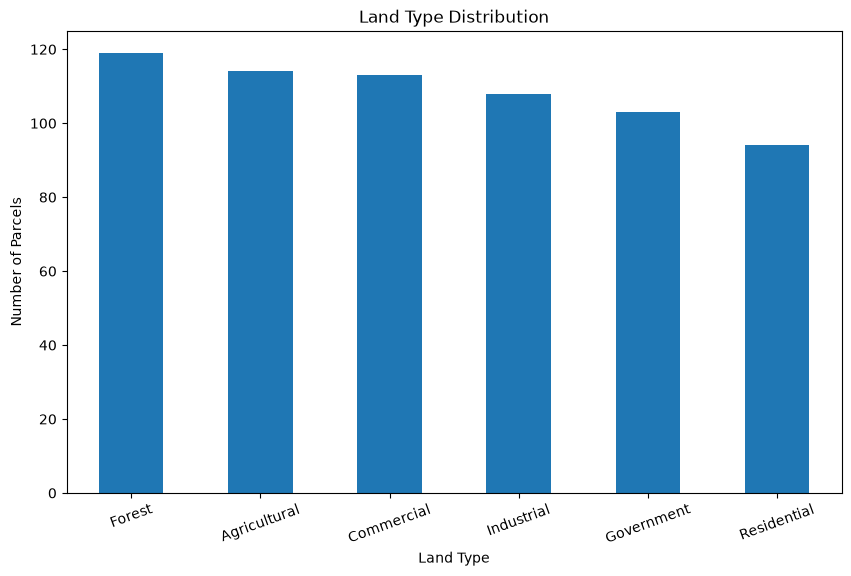

In [24]:
plt.figure(figsize=(10, 6))

df["land_type"].value_counts().plot(
    kind="bar"
)

plt.title("Land Type Distribution")
plt.xlabel("Land Type")
plt.ylabel("Number of Parcels")

plt.xticks(rotation=20)
plt.show()

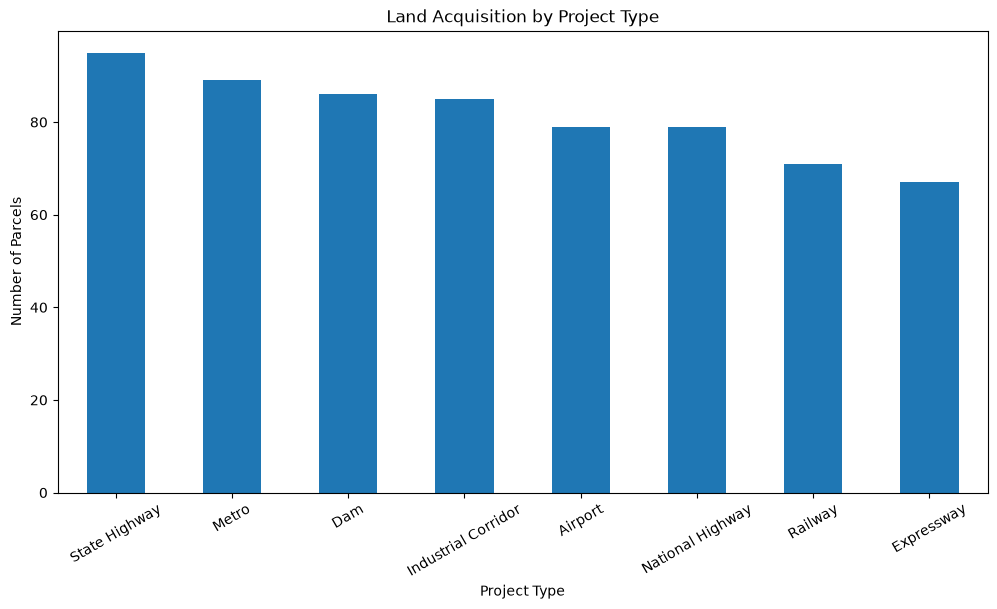

In [25]:
plt.figure(figsize=(12, 6))

df["project_type"].value_counts().plot(
    kind="bar"
)

plt.title("Land Acquisition by Project Type")
plt.xlabel("Project Type")
plt.ylabel("Number of Parcels")

plt.xticks(rotation=30)
plt.show()

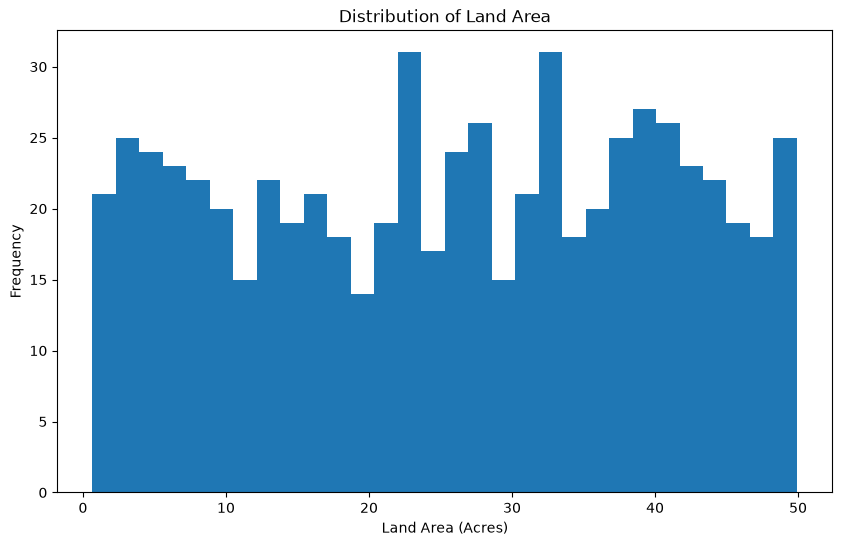

In [26]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["land_area_acres"],
    bins=30
)

plt.title("Distribution of Land Area")
plt.xlabel("Land Area (Acres)")
plt.ylabel("Frequency")

plt.show()

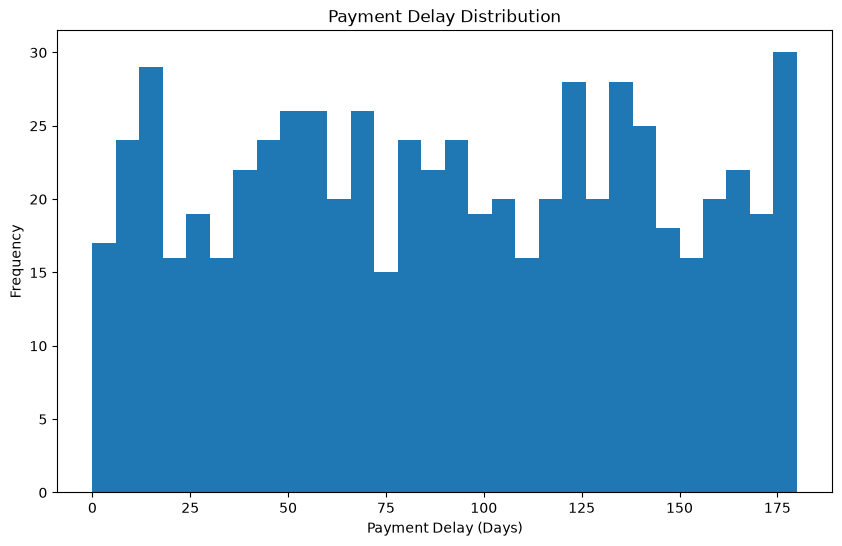

In [27]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["payment_delay_days"],
    bins=30
)

plt.title("Payment Delay Distribution")
plt.xlabel("Payment Delay (Days)")
plt.ylabel("Frequency")

plt.show()

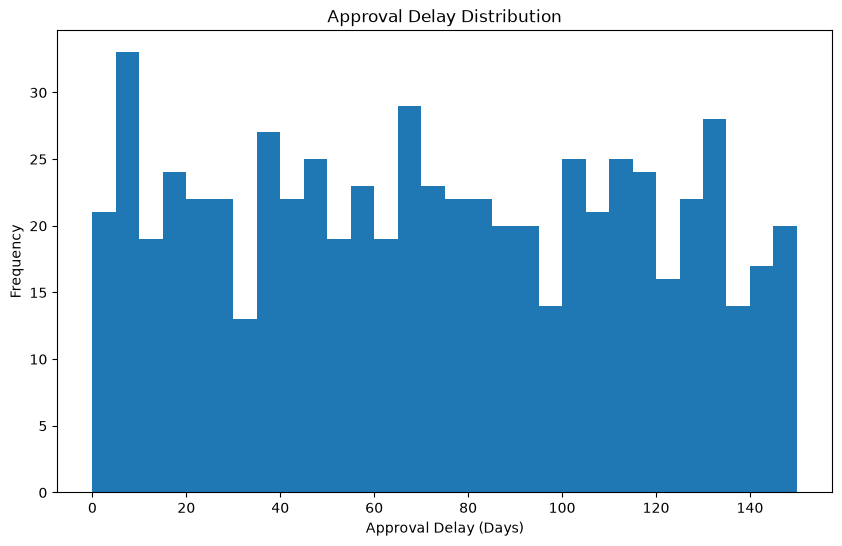

In [28]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["approval_delay_days"],
    bins=30
)

plt.title("Approval Delay Distribution")
plt.xlabel("Approval Delay (Days)")
plt.ylabel("Frequency")

plt.show()

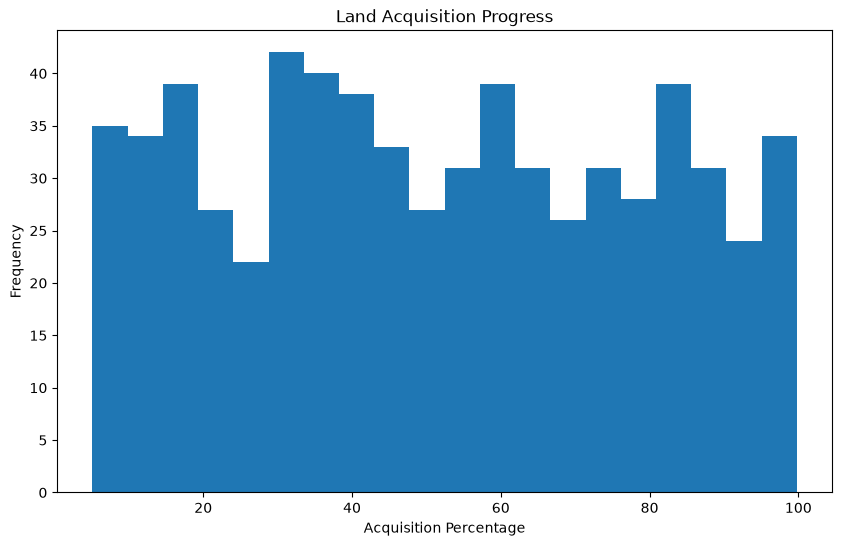

In [29]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["acquisition_percent"],
    bins=20
)

plt.title("Land Acquisition Progress")
plt.xlabel("Acquisition Percentage")
plt.ylabel("Frequency")

plt.show()

In [30]:
district_land = (
    df.groupby("district")["land_area_acres"]
    .sum()
    .sort_values(ascending=False)
)

district_land

district
Jalandhar          521.77
Coimbatore         490.60
Mangaluru          473.81
Tiruchirappalli    442.98
Jodhpur            435.45
                    ...  
Kolhapur            84.86
Aurangabad          78.94
Nagaur              59.95
Madurai             48.95
Ahmednagar          42.00
Name: land_area_acres, Length: 73, dtype: float64

In [31]:
print("========== SIH26016 SUMMARY ==========")

print("Total Records:",
      len(df))

print(
    "Total Land Area:",
    round(df["land_area_acres"].sum(), 2),
    "acres"
)

print(
    "Average Acquisition Progress:",
    round(df["acquisition_percent"].mean(), 2),
    "%"
)

print(
    "Average Payment Delay:",
    round(df["payment_delay_days"].mean(), 2),
    "days"
)

print(
    "Average Approval Delay:",
    round(df["approval_delay_days"].mean(), 2),
    "days"
)

print(
    "Ownership Disputes:",
    (df["ownership_dispute"] == "Yes").sum()
)

print(
    "High Risk Parcels:",
    (df["risk_level"] == "High").sum()
)

========== SIH26016 SUMMARY ==========
Total Records: 651
Total Land Area: 16716.2 acres
Average Acquisition Progress: 51.39 %
Average Payment Delay: 90.08 days
Average Approval Delay: 72.34 days
Ownership Disputes: 167
High Risk Parcels: 169
